<a href="https://www.kaggle.com/code/mrrogueknight/nutrition-health-survey-age-prediction?scriptVersionId=247130856" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nutrition-health-survey/Train_Data.csv
/kaggle/input/nutrition-health-survey/Test_Data.csv


In [12]:
# WARNING: This command will permanently delete all files and folders
# inside /kaggle/working/.

# First, list the files to see what will be deleted
print("--- Before Deletion ---")
!ls -l /kaggle/working/

# Now, delete everything inside the directory
!rm -rf /kaggle/working/*

# Verify that the directory is empty
print("\n--- After Deletion ---")
!ls -l /kaggle/working/

--- Before Deletion ---
total 1064
-rw-r--r-- 1 root root   3121 Jun 24 11:47 final_submission.csv
-rw-r--r-- 1 root root 490420 Jun 24 11:47 lgb_model.joblib
-rw-r--r-- 1 root root 592267 Jun 24 11:47 xgb_model.joblib

--- After Deletion ---
total 0


In [13]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
import os

# List all files in the dataset directory
os.listdir("/kaggle/input/nutrition-health-survey")

['Train_Data.csv', 'Test_Data.csv']

In [17]:
import pandas as pd
import numpy as np
import os
import logging
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_recall_curve
from joblib import dump

In [19]:
# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [20]:
# CONFIGURATION
CONFIG = {
    "xgb_params": {
        "n_estimators": 400,
        "learning_rate": 0.07,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42
    },
    "lgb_params": {
        "n_estimators": 400,
        "learning_rate": 0.07,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
        "random_state": 42,
        "verbose": -1
    },
    "folds": 5
}

Explanations:

    "n_estimators": 400,              # Number of boosting rounds (trees)
    "learning_rate": 0.07,            # Step size shrinkage (lower = slower but more accurate)
    "max_depth": 4,                   # Maximum depth of each tree (controls model complexity)
    "subsample": 0.8,                 # Fraction of rows (samples) to use per tree (reduces overfitting)
    "colsample_bytree": 0.8,          # Fraction of columns (features) used per tree (adds randomness)
    "use_label_encoder": False,       # Disable legacy label encoding (modern use)
    "eval_metric": "logloss",         # Evaluation metric (log loss for classification)
    "random_state": 42                # Random seed (ensures reproducibility)


    "n_estimators": 400,              # Number of boosting rounds (trees)
    "learning_rate": 0.07,            # Step size shrinkage
    "max_depth": 4,                   # Maximum depth of trees
    "subsample": 0.8,                 # Subsampling ratio of training instances
    "colsample_bytree": 0.8,          # Subsampling ratio of features
    "class_weight": "balanced",       # Automatically adjust weights based on class imbalance
    "random_state": 42,               # Seed for reproducibility
    "verbose": -1                     # Suppress LightGBM training logs and warnings

In [21]:
# PREPROCESSING
def preprocess(df):
    df = df.copy()
    df["BMI_Category"] = pd.cut(df["BMXBMI"], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(float)
    df["High_Glucose"] = (df["LBXGLU"] > 125).astype(float)
    df["Glu_Insulin"] = df["LBXGLU"] * df["LBXIN"]
    return df

def build_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])


In [22]:
# MODEL UTILITIES
def cross_validate(model, X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    f1s, thresholds = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]
        precision, recall, thresholds_all = precision_recall_curve(y_val, probs)
        f1_scores = 2 * precision * recall / (precision + recall + 1e-6)
        best_thresh = thresholds_all[np.argmax(f1_scores)]
        preds = (probs >= best_thresh).astype(int)
        score = f1_score(y_val, preds)
        
        f1s.append(score)
        thresholds.append(best_thresh)
        logging.info(f"Fold {fold}: F1 = {score:.4f}, Best Threshold = {best_thresh:.3f}")

    logging.info(f"Average F1 Score: {np.mean(f1s):.4f}")
    return np.mean(thresholds)

In [23]:
def plot_feature_importance(model, model_name, features, top_n=20):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[-top_n:]
        plt.figure(figsize=(8, 6))
        plt.barh(range(len(indices)), importances[indices], align='center')
        plt.yticks(range(len(indices)), [features[i] for i in indices])
        plt.title(f'{model_name} Feature Importances')
        plt.tight_layout()
        plt.show()

In [27]:
# # MAIN PIPELINE
# def run_pipeline(train_path, test_path, output_dir="."):
#     logging.info("Starting pipeline...")

#     # Load data
#     train_df = pd.read_csv(train_path)
#     test_df = pd.read_csv(test_path)
    
#     # Drop rows with missing target
#     train_df = train_df.dropna(subset=["age_group"])
#     y = train_df["age_group"].map({'Adult': 0, 'Senior': 1}).astype(int)
#     test_ids = test_df["SEQN"]
    
#     # Preprocess features
#     X = preprocess(train_df.drop(columns=["SEQN", "age_group"]))
#     X_test = preprocess(test_df.drop(columns=["SEQN"]))

#     features = X.columns.tolist()

#     # Build pipeline for imputation + scaling
#     pipe = build_pipeline()
#     X = pipe.fit_transform(X)
#     X_test = pipe.transform(X_test)

#     # Calculate scale_pos_weight for XGBoost
#     scale = (y == 0).sum() / (y == 1).sum()

#     # Initialize models
#     xgb_model = XGBClassifier(**CONFIG["xgb_params"], scale_pos_weight=scale)
#     lgb_model = LGBMClassifier(**CONFIG["lgb_params"])

#     # Cross-validate XGBoost and tune threshold
#     logging.info("XGBoost Cross-Validation")
#     best_thresh_xgb = cross_validate(xgb_model, X, y, folds=CONFIG["folds"])
#     xgb_model.fit(X, y)
#     probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
#     preds_xgb = (probs_xgb >= best_thresh_xgb).astype(int)
#     plot_feature_importance(xgb_model, "XGBoost", features)

#     # Cross-validate LightGBM and tune threshold
#     logging.info("LightGBM Cross-Validation")
#     best_thresh_lgb = cross_validate(lgb_model, X, y, folds=CONFIG["folds"])
#     lgb_model.fit(X, y)
#     probs_lgb = lgb_model.predict_proba(X_test)[:, 1]
#     preds_lgb = (probs_lgb >= best_thresh_lgb).astype(int)
#     plot_feature_importance(lgb_model, "LightGBM", features)

#     # Ensemble predictions by averaging probabilities
#     logging.info("Ensembling predictions")
#     final_probs = (probs_xgb + probs_lgb) / 2
#     final_preds = (final_probs >= 0.5).astype(int)

#     # Save submissions
#     submission = pd.DataFrame({"SEQN": test_ids, "age_group": final_preds})
#     submission_path = os.path.join(output_dir, "final_submission.csv")
#     submission.to_csv(submission_path, index=False)
#     logging.info(f"Submission saved to: {submission_path}")

#     # Save models
#     dump(xgb_model, os.path.join(output_dir, "xgb_model.joblib"))
#     dump(lgb_model, os.path.join(output_dir, "lgb_model.joblib"))
#     logging.info("Models saved.")

In [29]:
def load_and_prepare_data(train_path, test_path):
    logging.info("📥 Loading and preparing data...")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    train_df = train_df.dropna(subset=["age_group"])
    y = train_df["age_group"].map({'Adult': 0, 'Senior': 1}).astype(int)
    test_ids = test_df["SEQN"]

    X = preprocess(train_df.drop(columns=["SEQN", "age_group"]))
    X_test = preprocess(test_df.drop(columns=["SEQN"]))
    features = X.columns.tolist()

    return X, X_test, y, test_ids, features

In [30]:
X, X_test, y, test_ids, features = load_and_prepare_data(
    "/kaggle/input/nutrition-health-survey/Train_Data.csv",
    "/kaggle/input/nutrition-health-survey/Test_Data.csv"
)

In [31]:
pipe = build_pipeline()
X = pipe.fit_transform(X)
X_test = pipe.transform(X_test)

In [32]:
scale = (y == 0).sum() / (y == 1).sum()
xgb_model = XGBClassifier(**CONFIG["xgb_params"], scale_pos_weight=scale)
lgb_model = LGBMClassifier(**CONFIG["lgb_params"])

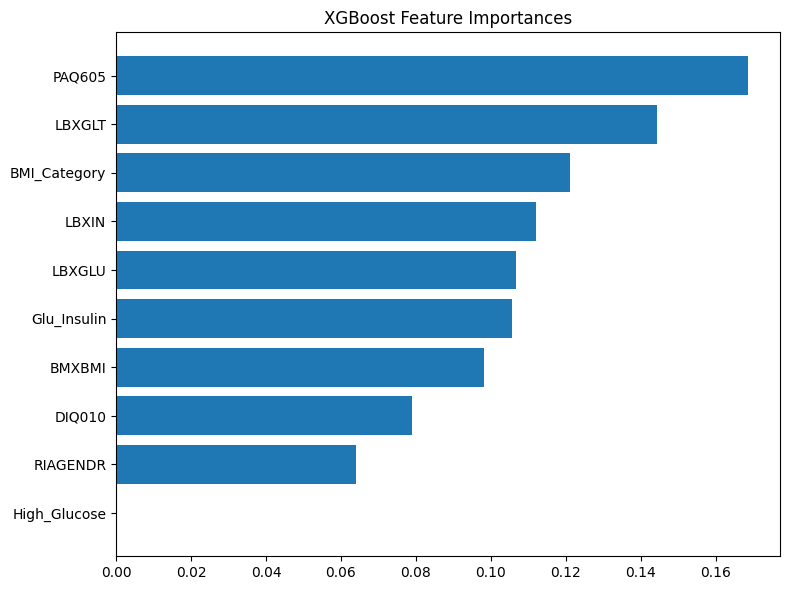

In [33]:
logging.info("XGBoost Cross-Validation")
best_thresh_xgb = cross_validate(xgb_model, X, y, folds=CONFIG["folds"])
xgb_model.fit(X, y)
probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
plot_feature_importance(xgb_model, "XGBoost", features)

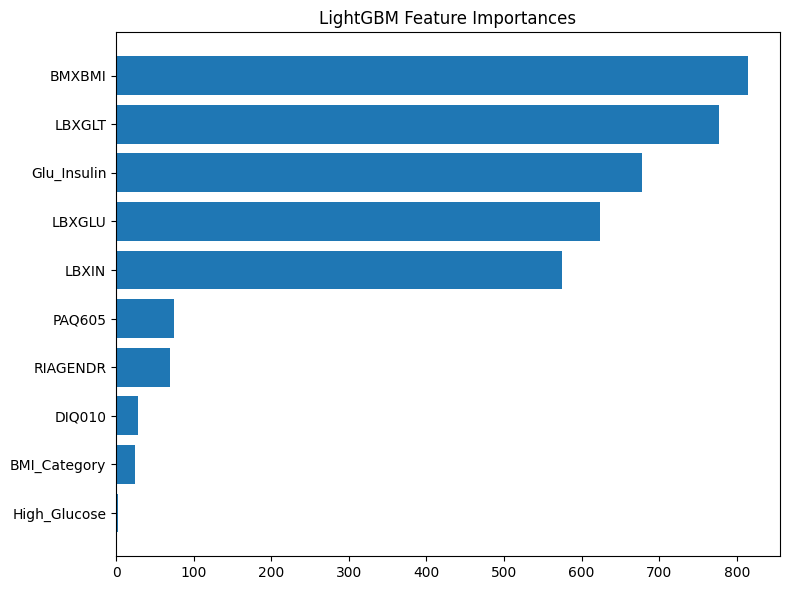

In [34]:
logging.info("LightGBM Cross-Validation")
best_thresh_lgb = cross_validate(lgb_model, X, y, folds=CONFIG["folds"])
lgb_model.fit(X, y)
probs_lgb = lgb_model.predict_proba(X_test)[:, 1]
plot_feature_importance(lgb_model, "LightGBM", features)

In [35]:
logging.info("Ensembling predictions")
final_probs = (probs_xgb + probs_lgb) / 2
final_preds = (final_probs >= 0.5).astype(int)

submission = pd.DataFrame({"SEQN": test_ids, "age_group": final_preds})
submission_path = os.path.join("/kaggle/working", "final_submission.csv")
submission.to_csv(submission_path, index=False)
logging.info(f"Submission saved to: {submission_path}")

In [36]:
dump(xgb_model, os.path.join("/kaggle/working", "xgb_model.joblib"))
dump(lgb_model, os.path.join("/kaggle/working", "lgb_model.joblib"))
logging.info("Models saved.")

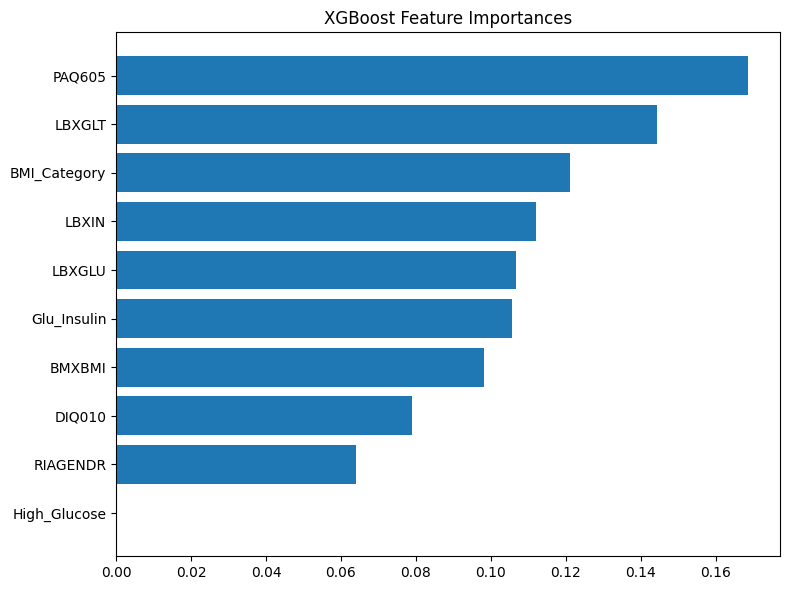

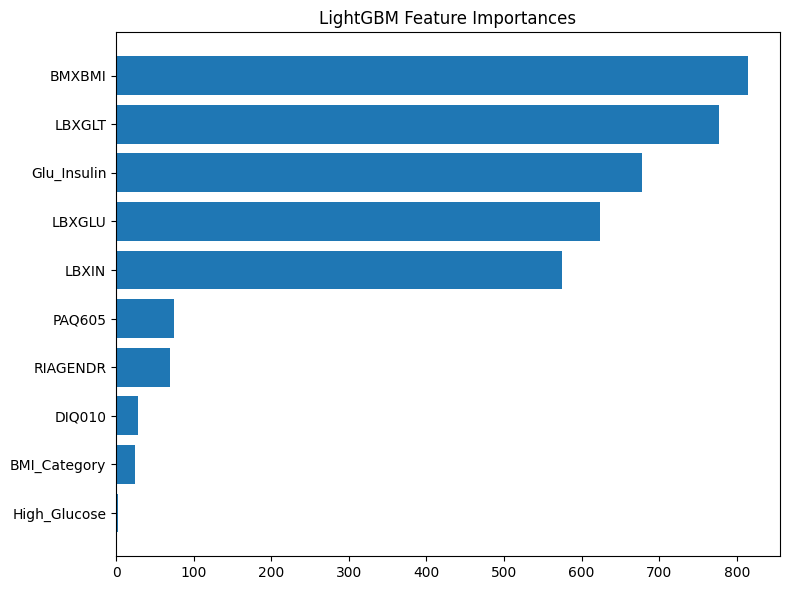

In [37]:
# RUN PIPELINE
if __name__ == "__main__":
    run_pipeline(
        train_path="/kaggle/input/nutrition-health-survey/Train_Data.csv",
        test_path="/kaggle/input/nutrition-health-survey/Test_Data.csv",
        output_dir="/kaggle/working"
    )
